# Medical Insurance Cost Prediction 

## Libraries and Global Configuration

In [50]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.init as init
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
from torch.utils.tensorboard import SummaryWriter

# Configure visual style and seeds for reproducibility
sns.set_theme(style="whitegrid")
torch.manual_seed(42)
np.random.seed(42)

print("Environment ready.")

Environment ready.


## Data Loading and Initial Inspections

In [51]:

df = pd.read_csv('insurance.csv')

print("--- Dataset Head ---")
display(df.head())

print("\n--- General Information and Null Values ---")
df.info()
print("\nNull values per column:\n", df.isnull().sum())

print("\n--- Descriptive Statistics ---")
display(df.describe())

--- Dataset Head ---


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520



--- General Information and Null Values ---
<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB

Null values per column:
 age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

--- Descriptive Statistics ---


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


# Exploratory Data Analysis (EDA):

In [52]:
print("--- PRIMERAS FILAS DEL DATASET ---")
display(df.head())

print("\n--- INFORMACIÓN GENERAL Y VALORES NULOS ---")
display(df.info())
print("Valores nulos por columna:\n", df.isnull().sum())

print("\n--- ESTADÍSTICAS DESCRIPTIVAS ---")
display(df.describe())

--- PRIMERAS FILAS DEL DATASET ---


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520



--- INFORMACIÓN GENERAL Y VALORES NULOS ---
<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


None

Valores nulos por columna:
 age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

--- ESTADÍSTICAS DESCRIPTIVAS ---


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


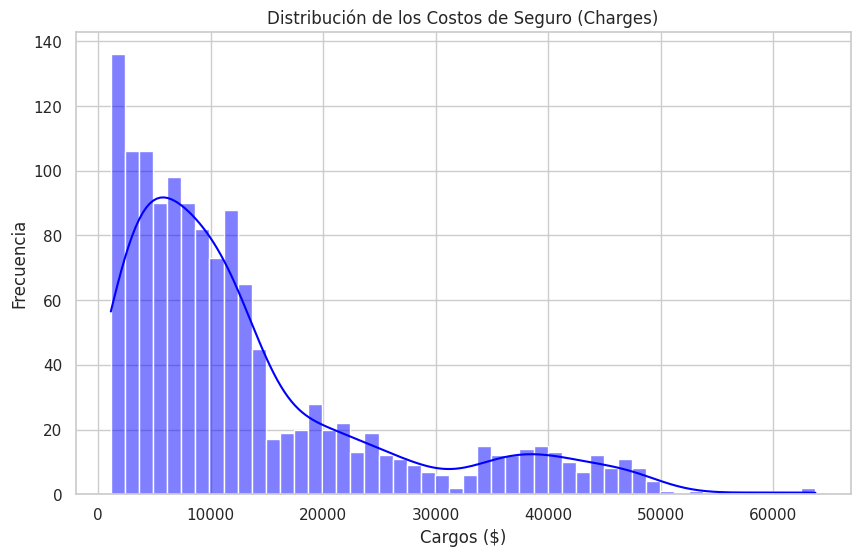

In [53]:
plt.figure(figsize=(10, 6))
sns.histplot(df['charges'], kde=True, color='blue', bins=50)
plt.title('Distribución de los Costos de Seguro (Charges)')
plt.xlabel('Cargos ($)')
plt.ylabel('Frecuencia')
plt.show()

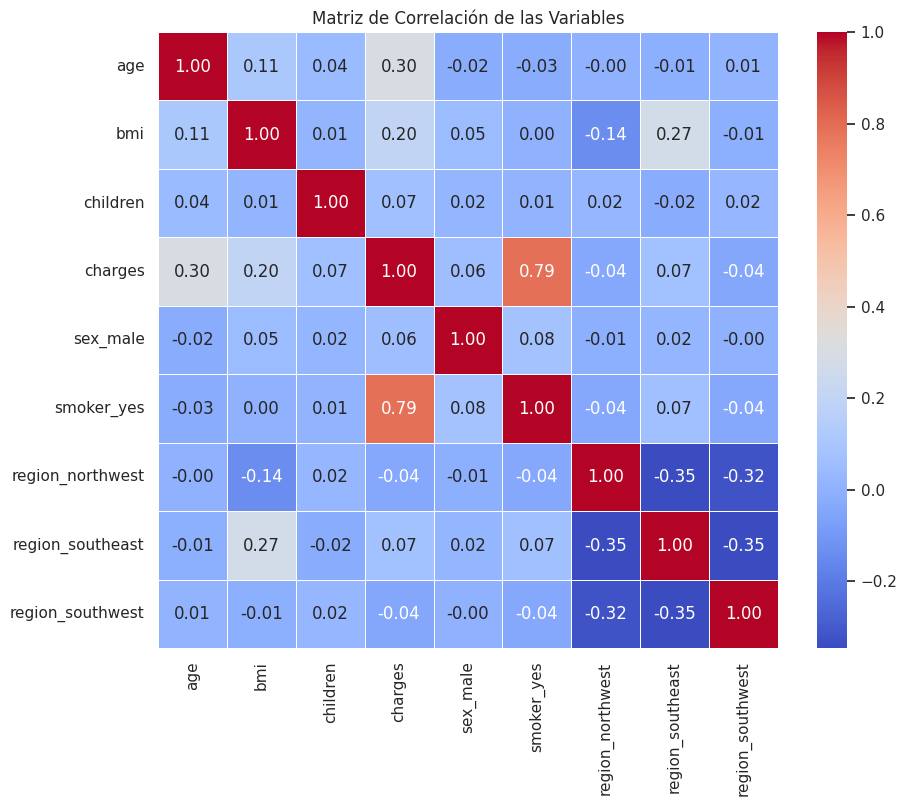

In [56]:
plt.figure(figsize=(10, 8))
# Calculamos la correlación
correlacion = df.corr()
# Dibujamos un mapa de calor (heatmap)
sns.heatmap(correlacion, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación de las Variables')
plt.show()

/tmp/ipykernel_97286/790347924.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0], x='smoker_yes', y='charges', data=df, palette='Set2')


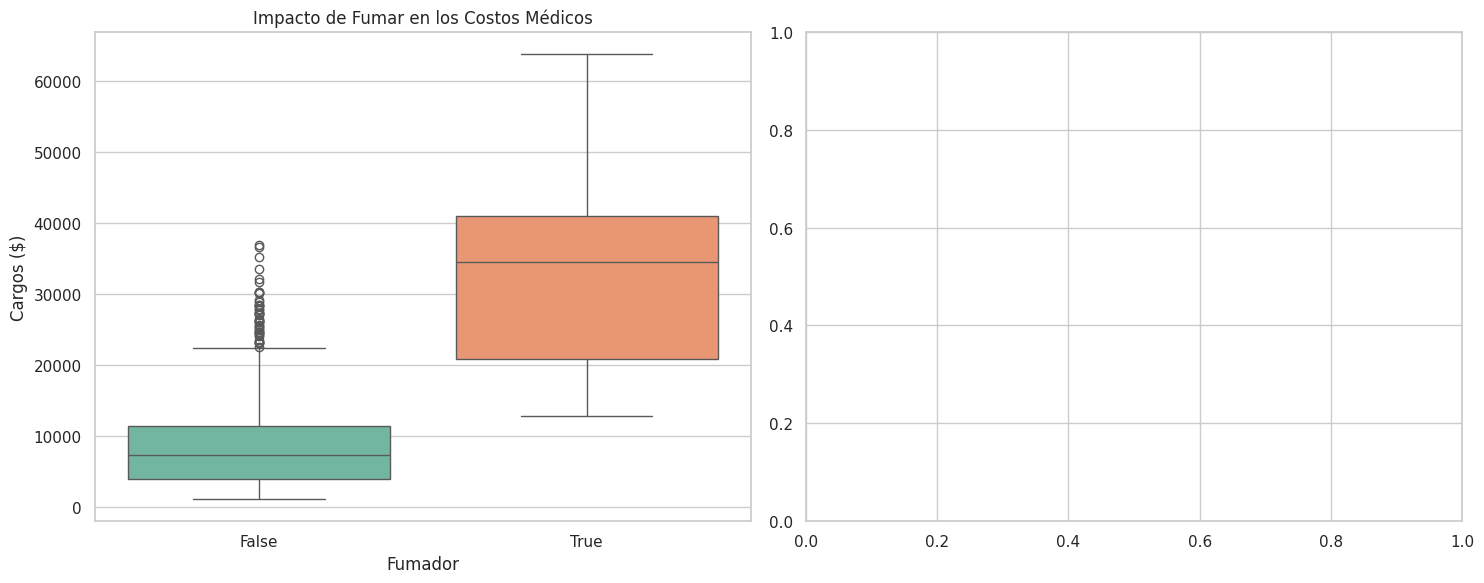

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Boxplot: Fumador vs Cargos
sns.boxplot(ax=axes[0], x='smoker_yes', y='charges', data=df, palette='Set2')
axes[0].set_title('Impacto de Fumar en los Costos Médicos')
axes[0].set_xlabel('Fumador')
axes[0].set_ylabel('Cargos ($)')



plt.tight_layout()
plt.show()

## Data Preprocessing

In [55]:
# Transformamos categorías en columnas de 0 y 1 ya que nuestro modelo no puede trabajar con texto porque las redes neuronales trabajan con números, no con texto.
df = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)   #el drop_first=True es para evitar redundacia, es decir que si no es hombre, entonces es mujer, si no es fumador, entonces es no fumador, etc.

# Separamos las características (X) de la variable objetivo (y) que es 'charges'. 
X = df.drop('charges', axis=1).values
y = df['charges'].values.reshape(-1, 1)

# Separamos 80% para entrenar y 20% para el resto
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)

# Ese 20% lo dividimos en dos: 10% para Validar y 10% para el Test final
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

## Scaling and Tensors Conversion

In [58]:
#Estandarizamos los datos porque las redes neuronales funcionan mejor con datos centrados y escalados
#Si no lo hacemos, algunas características podrían dominar a otras debido a sus diferentes escalas, lo que podría dificultar el aprendizaje del modelo.
scaler = StandardScaler()

# Ajustamos el scaler solo con los datos de entrenamiento para evitar "fugas de información" 
X_train = scaler.fit_transform(X_train)

# Luego transformamos los datos de validación y test usando el mismo scaler para mantener la consistencia
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)



# La red neuronal no entiende tablas de Excel o listas normales, solo entiende "Tensores".
# Convertimos los números a Floats (decimales) para que el motor de PyTorch pueda hacer cálculos rápidos.
X_train = torch.FloatTensor(X_train)
y_train = torch.FloatTensor(y_train)
X_val = torch.FloatTensor(X_val)
y_val = torch.FloatTensor(y_val)

X_test, y_test = torch.FloatTensor(X_test), torch.FloatTensor(y_test)

# Base Model (Linear Regression)

In [59]:

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. Entrenamos el modelo tradicional (Regresión Lineal)
# Usamos los datos antes de ser Tensores (X_train, y_train en formato numpy)
modelo_base = LinearRegression()
modelo_base.fit(X_train.numpy(), y_train.numpy())

# 2. Hacemos predicciones sobre el set de Test
predicciones_base = modelo_base.predict(X_test.numpy())

# 3. Calculamos métricas para tener una referencia
rmse_base = np.sqrt(mean_squared_error(y_test.numpy(), predicciones_base))
mae_base = mean_absolute_error(y_test.numpy(), predicciones_base)

print("--- RESULTADOS DEL MODELO BASE (REGRESIÓN LINEAL) ---")
print(f"Error RMSE (Base): ${rmse_base:.2f}")
print(f"Error MAE (Base): ${mae_base:.2f}")
print("-" * 50)

--- RESULTADOS DEL MODELO BASE (REGRESIÓN LINEAL) ---
Error RMSE (Base): $6012.14
Error MAE (Base): $4320.94
--------------------------------------------------


# Red Neuronal y Entrenamiento

In [60]:
class RedNeuronalSeguros(nn.Module):
    # Añadimos n1 y n2 aquí para que Optuna pueda modificarlos
    def __init__(self, input_size, n1=64, n2=32): 
        super(RedNeuronalSeguros, self).__init__()
        self.capa1 = nn.Linear(input_size, n1)
        self.capa2 = nn.Linear(n1, n2)
        self.capa_salida = nn.Linear(n2, 1)
        self.relu = nn.ReLU()
        
        init.kaiming_uniform_(self.capa1.weight, nonlinearity='relu')
        init.kaiming_uniform_(self.capa2.weight, nonlinearity='relu')
        
    def forward(self, x):
        x = self.relu(self.capa1(x))
        x = self.relu(self.capa2(x))
        x = self.capa_salida(x)
        return x

In [61]:
def entrenar_modelo(modelo, criterion, optimizer, X_train, y_train, X_test, y_test, epochs=500):
    historial_train = []
    historial_val = []
    
    writer = SummaryWriter('runs/experimento_base')
    
    for epoch in range(epochs):
        # Entrenamiento
        modelo.train()
        optimizer.zero_grad()
        predicciones = modelo(X_train)
        loss = criterion(predicciones, y_train)
        loss.backward()
        optimizer.step()
        historial_train.append(loss.item())
        
        # Validación
        modelo.eval()
        with torch.no_grad():
            pred_val = modelo(X_test)
            loss_val = criterion(pred_val, y_test)
            historial_val.append(loss_val.item())
            
        # TensorBoard
        writer.add_scalar('Loss/Train', loss.item(), epoch)
        writer.add_scalar('Loss/Validation', loss_val.item(), epoch)
        
        if (epoch + 1) % 50 == 0:
            print(f'Época {epoch+1}/{epochs} | MSE Train: {loss.item():.2f} | MSE Val: {loss_val.item():.2f}')
            
    writer.close()
    return historial_train, historial_val

In [62]:
# Instanciamos el modelo
input_size = X_train.shape[1] 
modelo_dl = RedNeuronalSeguros(input_size)

# Definimos pérdida y optimizador
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(modelo_dl.parameters(), lr=0.01)

# Entrenamos (Esto llenará las listas de tu compañera)
historial_train, historial_val = entrenar_modelo(
    modelo_dl, criterion, optimizer, 
    X_train, y_train, X_test, y_test, 
    epochs=500
)

# Predicciones finales para que la gráfica 2 de tu compañera funcione
modelo_dl.eval()
with torch.no_grad():
    predicciones_finales = modelo_dl(X_test)
    
print("¡Entrenamiento finalizado!")

Época 50/500 | MSE Train: 307362688.00 | MSE Val: 332547584.00
Época 100/500 | MSE Train: 166918672.00 | MSE Val: 176984800.00
Época 150/500 | MSE Train: 53600484.00 | MSE Val: 50564116.00
Época 200/500 | MSE Train: 37630988.00 | MSE Val: 36266608.00
Época 250/500 | MSE Train: 34336376.00 | MSE Val: 33364032.00
Época 300/500 | MSE Train: 33402340.00 | MSE Val: 32724656.00
Época 350/500 | MSE Train: 32774056.00 | MSE Val: 32381852.00
Época 400/500 | MSE Train: 32236646.00 | MSE Val: 32108074.00
Época 450/500 | MSE Train: 31688260.00 | MSE Val: 31811446.00
Época 500/500 | MSE Train: 31122496.00 | MSE Val: 31502152.00
¡Entrenamiento finalizado!


## Optuna

In [63]:
import optuna

def objective(trial):
    # 1. Sugerimos hiperparámetros
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    # Pongo step=16 para que pruebe números "redondos" típicos en DL (32, 48, 64...)
    n1 = trial.suggest_int("n1", 32, 256, step=16) 
    n2 = trial.suggest_int("n2", 16, 128, step=16)
    
    # 2. Reutilizamos nuestra clase modular (¡Esto da mucha nota!)
    model_opt = RedNeuronalSeguros(input_size=X_train.shape[1], n1=n1, n2=n2)
    optimizer_opt = torch.optim.Adam(model_opt.parameters(), lr=lr)
    criterion_opt = nn.MSELoss()

    # 3. Entrenamiento rápido (200 épocas)
    for epoch in range(200):
        model_opt.train()
        optimizer_opt.zero_grad()
        loss = criterion_opt(model_opt(X_train), y_train)
        loss.backward()
        optimizer_opt.step()
    
    # 4. Evaluamos con el set de VALIDACIÓN (Usamos X_test, y_test)
    model_opt.eval()
    with torch.no_grad():
        v_loss = criterion_opt(model_opt(X_test), y_test)
    
    return np.sqrt(v_loss.item()) # Optuna intentará minimizar este RMSE

# Lanzamos el estudio (hará 20 intentos automáticos)
# Optuna probará 20 redes distintas y se quedará con la mejor
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=20)

print("\n--- ¡BÚSQUEDA FINALIZADA! ---")
print(f"Mejor RMSE encontrado: ${study.best_value:.2f}")
print(f"Mejores parámetros: {study.best_params}")

[I 2026-03-24 17:28:36,131] A new study created in memory with name: no-name-c56c1bfa-bec3-45ba-8840-b0e95a202357
[I 2026-03-24 17:28:36,522] Trial 0 finished with value: 18639.25663753788 and parameters: {'lr': 0.0002704858959665239, 'n1': 144, 'n2': 112}. Best is trial 0 with value: 18639.25663753788.
[I 2026-03-24 17:28:36,862] Trial 1 finished with value: 18452.695846406834 and parameters: {'lr': 0.0008721308212323657, 'n1': 208, 'n2': 32}. Best is trial 1 with value: 18452.695846406834.
[I 2026-03-24 17:28:37,121] Trial 2 finished with value: 18690.99890321542 and parameters: {'lr': 0.00011615451986443703, 'n1': 128, 'n2': 16}. Best is trial 1 with value: 18452.695846406834.
[I 2026-03-24 17:28:37,644] Trial 3 finished with value: 18683.499458077975 and parameters: {'lr': 0.00010734939953090816, 'n1': 256, 'n2': 48}. Best is trial 1 with value: 18452.695846406834.
[I 2026-03-24 17:28:38,273] Trial 4 finished with value: 18591.085175427495 and parameters: {'lr': 0.00033256743104682


--- ¡BÚSQUEDA FINALIZADA! ---
Mejor RMSE encontrado: $5546.45
Mejores parámetros: {'lr': 0.009800707480575259, 'n1': 192, 'n2': 96}


In [64]:
# 1. Extraemos los mejores parámetros del estudio de Optuna
mejores_params = study.best_params
print(f"Construyendo modelo definitivo con: {mejores_params}")

# 2. Reutilizamos nuestra clase modular con los "números mágicos"
modelo_final = RedNeuronalSeguros(
    input_size=X_train.shape[1], 
    n1=mejores_params['n1'], 
    n2=mejores_params['n2']
)

# 3. Definimos pérdida y el optimizador con el Learning Rate perfecto
criterion_final = nn.MSELoss()
optimizer_final = torch.optim.Adam(modelo_final.parameters(), lr=mejores_params['lr'])

# 4. ¡Entrenamos el modelo definitivo! 
# Esto sobrescribirá los historiales antiguos para que las gráficas muestren la versión pro
print("\nIniciando entrenamiento final...")
historial_train, historial_val = entrenar_modelo(
    modelo_final, criterion_final, optimizer_final, 
    X_train, y_train, X_test, y_test, 
    epochs=600  # Le damos un poco más de tiempo para que aprenda al máximo
)

# 5. Hacemos las predicciones finales para que la gráfica 2 de tu compañera funcione
modelo_final.eval()
with torch.no_grad():
    predicciones_finales = modelo_final(X_test)

# 6. Calculamos la métrica final (RMSE) para presumir en la presentación
#Convertimos el error en DÓLARES que es lo que entendemos nosotros
# Como usamos MSE, hacemos la raíz cuadrada para tener el RMSE
from sklearn.metrics import mean_squared_error
rmse_final = mean_squared_error(y_test, predicciones_finales.numpy()) ** 0.5

print(f"\n---  RESULTADO DEFINITIVO  ---")
print(f"RMSE de la Regresión Lineal (Modelo Base): ${rmse_base:.2f}")
print(f"RMSE de la Red Neuronal Optimizada:        ${rmse_final:.2f}")

Construyendo modelo definitivo con: {'lr': 0.009800707480575259, 'n1': 192, 'n2': 96}

Iniciando entrenamiento final...
Época 50/600 | MSE Train: 188398608.00 | MSE Val: 200387248.00
Época 100/600 | MSE Train: 40689264.00 | MSE Val: 39130156.00
Época 150/600 | MSE Train: 32649694.00 | MSE Val: 31678666.00
Época 200/600 | MSE Train: 30771408.00 | MSE Val: 30526780.00
Época 250/600 | MSE Train: 28978474.00 | MSE Val: 29047468.00
Época 300/600 | MSE Train: 27438400.00 | MSE Val: 27559736.00
Época 350/600 | MSE Train: 26314092.00 | MSE Val: 26468688.00
Época 400/600 | MSE Train: 25482318.00 | MSE Val: 25693566.00
Época 450/600 | MSE Train: 24820268.00 | MSE Val: 25125160.00
Época 500/600 | MSE Train: 24277194.00 | MSE Val: 24777840.00
Época 550/600 | MSE Train: 23814830.00 | MSE Val: 24474466.00
Época 600/600 | MSE Train: 23413580.00 | MSE Val: 24290838.00

---  RESULTADO DEFINITIVO  ---
RMSE de la Regresión Lineal (Modelo Base): $6012.14
RMSE de la Red Neuronal Optimizada:        $4928.57

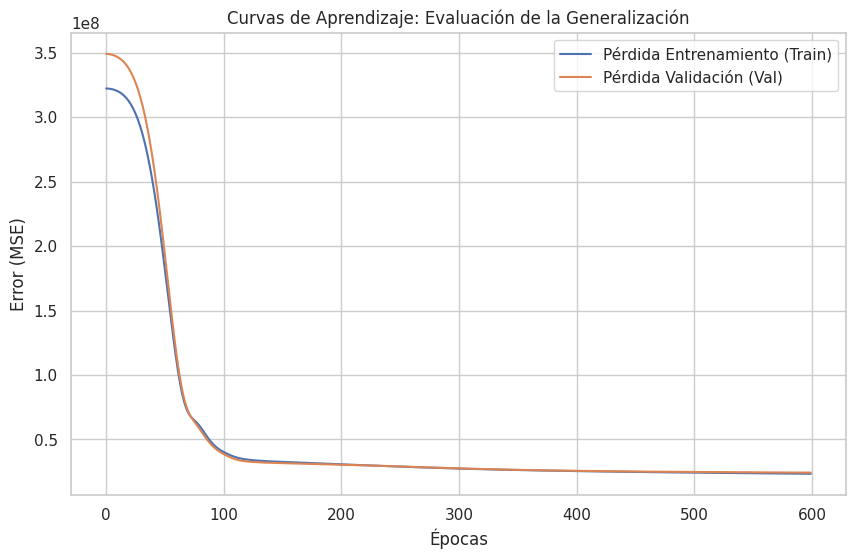

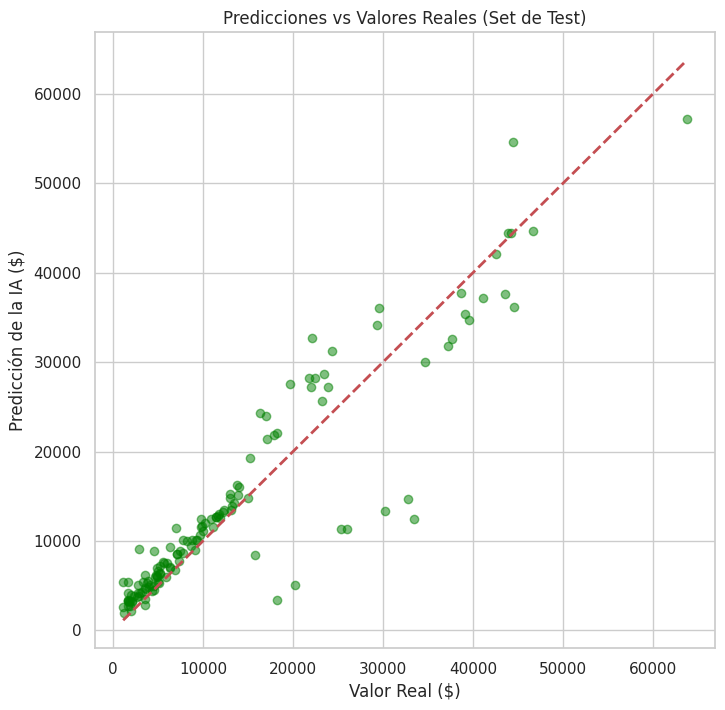

In [65]:


# GRÁFICA DE PÉRDIDA (Comprobación de Overfitting)
# Aquí usamos historial_train e historial_val que llenaste en el bucle
plt.figure(figsize=(10, 6))
plt.plot(historial_train, label='Pérdida Entrenamiento (Train)')
plt.plot(historial_val, label='Pérdida Validación (Val)')
plt.title('Curvas de Aprendizaje: Evaluación de la Generalización')
plt.xlabel('Épocas')
plt.ylabel('Error (MSE)')
plt.legend()
plt.show()

# 2. GRÁFICA DE PREDICCIÓN VS REALIDAD
# Vamos a ver visualmente cuánto se alejan los puntos de la realidad
plt.figure(figsize=(8, 8))
plt.scatter(y_test, predicciones_finales, alpha=0.5, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Predicciones vs Valores Reales (Set de Test)')
plt.xlabel('Valor Real ($)')
plt.ylabel('Predicción de la IA ($)')
plt.show()